# Configuration

In [1]:
import os 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

from tqdm import tqdm
import pickle

In [2]:
import pandas as pd 
import numpy as np

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

In [4]:
from statsmodels.regression.linear_model import OLS
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from scipy.special import expit
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from scipy.optimize import minimize, minimize_scalar

In [5]:
from core.variables import * 
import core.pricing as pricing
import core.dgp as dgp 

# DGP

In [6]:
dgp = dgp.Pricing(seed=0)
data = dgp.sample(7866, seed=None)

train_df, test_df = train_test_split(data, test_size=0.1, random_state=0)

test_customers = test_df[[col for col in test_df.columns if col.startswith('cov_')]].values
test_prices = test_df['price'].values

# Demand Model

In [9]:
# fit model
mle_logit = pricing.MLELogit().fit(data)

mle_logit_eval_dict = mle_logit.evaluate(test_customers, test_prices, dgp)

print(f'Accuracy: {100 * mle_logit_eval_dict["accuracy"]:.2f}%')
print(f'RMSE: {mle_logit_eval_dict["rmse"]:.4f}')

Accuracy: 87.04%
RMSE: 0.0831


In [10]:
# fit model
lasso_logit = pricing.LassoLogit().fit(data)

lasso_eval_dict = lasso_logit.evaluate(test_customers, test_prices, dgp)

print(f'Accuracy: {100 * lasso_eval_dict["accuracy"]:.2f}%')
print(f'RMSE: {lasso_eval_dict["rmse"]:.4f}')

Accuracy: 92.25%
RMSE: 0.0472


In [9]:
# fit model
wlb_mle = pricing.WLBMLELogit(n_bootstraps=100).fit(data, seed=0, verbose=True, n_jobs=-1)

wlb_mle_eval_dict = wlb_mle.evaluate(test_customers, test_prices, dgp)

avg_acc, std_acc = np.mean(wlb_mle_eval_dict['accuracy']), np.std(wlb_mle_eval_dict['accuracy'])
avg_rmse, std_rmse = np.mean(wlb_mle_eval_dict['rmse']), np.std(wlb_mle_eval_dict['rmse'])

print(f'Accuracy: {100 * avg_acc:.2f}% ({100 * std_acc:.2f}%)')
print(f'RMSE: {avg_rmse:.2f}% ({std_rmse:.2f}%)')

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    4.3s


Accuracy: 76.05% (2.06%)
RMSE: 0.19% (0.01%)


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    9.3s finished


In [10]:
# fit model
wlb_lasso = pricing.WLBLassoLogit(n_bootstraps=100).fit(data, seed=0, verbose=True, n_jobs=-1)

wlb_lasso_eval_dict = wlb_lasso.evaluate(test_customers, test_prices, dgp)

avg_acc, std_acc = np.mean(wlb_lasso_eval_dict['accuracy']), np.std(wlb_lasso_eval_dict['accuracy'])
avg_rmse, std_rmse = np.mean(wlb_lasso_eval_dict['rmse']), np.std(wlb_lasso_eval_dict['rmse'])

print(f'Accuracy: {100 * avg_acc:.2f}% ({100 * std_acc:.2f}%)')
print(f'RMSE: {avg_rmse:.2f}% ({std_rmse:.2f}%)')

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    1.4s


Accuracy: 85.62% (1.72%)
RMSE: 0.09% (0.01%)


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    4.2s finished


In [11]:
test_performances = {
    'mle': {
        'accuracy': 100 * mle_logit_eval_dict['accuracy'], 
        'rmse': mle_logit_eval_dict['rmse']
    }, 
    'lasso': {
        'accuracy': 100 * lasso_eval_dict['accuracy'], 
        'rmse': lasso_eval_dict['rmse']
    }, 
    'wlb-mle': {
        'accuracy': 100 * np.mean(wlb_mle_eval_dict['accuracy']), 
        'rmse': np.mean(wlb_mle_eval_dict['rmse'])
    }, 
    'wlb-lasso': {
        'accuracy': 100 * np.mean(wlb_lasso_eval_dict['accuracy']), 
        'rmse': np.mean(wlb_lasso_eval_dict['rmse'])
    }
}
pd.DataFrame.from_dict(test_performances).T

,accuracy,rmse
mle,87.039390,0.083135
lasso,92.249047,0.047207
wlb-mle,76.045743,0.189741
wlb-lasso,85.617535,0.093749


# Optimization

In [12]:
opt_prices, pricing_val = pricing.optimize(
    customers=test_customers, demand_model=dgp
)
print(f'Clairvoyant:\n Best pricing value: {pricing_val:.4f}')

opt_prices, pricing_val_est = pricing.optimize(
    customers=test_customers, demand_model=mle_logit,
)
true_pricing_val = pricing.obj_func(customers=test_customers, prices=opt_prices, demand_model=dgp)
print(f'MLE:\n Estimated pricing value: {pricing_val_est:.4f}, True pricing value: {true_pricing_val:.4f}')

opt_prices, pricing_val_est = pricing.optimize(
    customers=test_customers, demand_model=lasso_logit,
)
true_pricing_val = pricing.obj_func(customers=test_customers, prices=opt_prices, demand_model=dgp)
print(f'Lasso:\n Estimated pricing value: {pricing_val_est:.4f}, True pricing value: {true_pricing_val:.4f}')

opt_prices, pricing_val_est = pricing.optimize(
    customers=test_customers, demand_model=wlb_mle
)
true_pricing_val = pricing.obj_func(customers=test_customers, prices=opt_prices, demand_model=dgp)
print(f'WLB MLE:\n Estimated pricing value: {pricing_val_est:.4f}, True pricing value: {true_pricing_val:.4f}')

opt_prices, pricing_val_est = pricing.optimize(
    customers=test_customers, demand_model=wlb_lasso,
)
true_pricing_val = pricing.obj_func(customers=test_customers, prices=opt_prices, demand_model=dgp)
print(f'WLB Lasso:\n Estimated pricing value: {pricing_val_est:.4f}, True pricing value: {true_pricing_val:.4f}')

Clairvoyant:
 Best pricing value: 0.1051
MLE:
 Estimated pricing value: 0.2764, True pricing value: 0.0923
Lasso:
 Estimated pricing value: 0.1035, True pricing value: 0.1028
WLB MLE:
 Estimated pricing value: 1.3284, True pricing value: 0.0041
WLB Lasso:
 Estimated pricing value: 0.1041, True pricing value: 0.1034


## Visualizing objective function

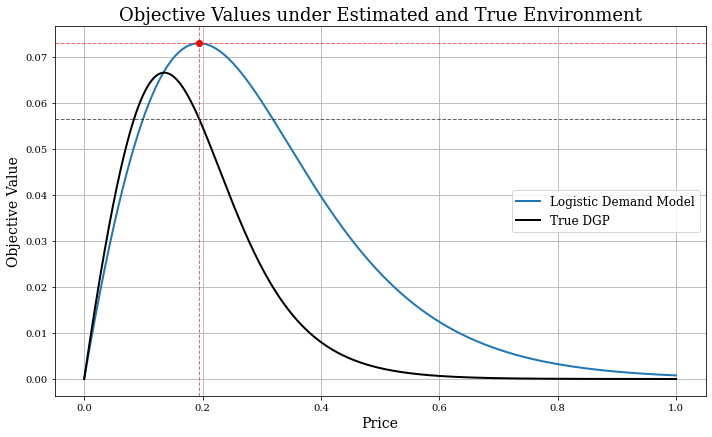

In [13]:
test_consumer = dgp.sample_individuals(1, seed=0)

price_arr = np.linspace(0, 1, 1000)

ldm_obj_val_arr = np.array([pricing.obj_func(test_consumer, np.array([price]), lasso_logit) for price in price_arr])
plugin_price, plugin_obj_val = pricing.optimize(test_consumer, lasso_logit)
actual_obj_val = pricing.obj_func(test_consumer, plugin_price, dgp)
plugin_price = plugin_price[0]

dgp_obj_val_arr = np.array([pricing.obj_func(test_consumer, np.array([price]), dgp) for price in price_arr])

fig, ax = plt.subplots(figsize=(10, 6.18))

# 
ax.plot(price_arr, ldm_obj_val_arr, color='C0', lw=2, label='Logistic Demand Model')
ax.plot(plugin_price, plugin_obj_val, 'ro', markersize=6)

# 
ax.plot(price_arr, dgp_obj_val_arr, color='black', lw=2, label='True DGP')

# plot plugin price and its performances
ax.axvline(plugin_price, color='red', linestyle='--', lw=1, alpha=0.6)
ax.axhline(plugin_obj_val, color='red', linestyle='--', lw=1, alpha=0.6)
ax.axhline(actual_obj_val, color='black', linestyle='--', lw=1, alpha=0.6)

ax.set_xlabel('Price', fontsize=axis_label_size)
ax.set_ylabel('Objective Value', fontsize=axis_label_size)
ax.set_title('Objective Values under Estimated and True Environment', fontsize=title_size)

plt.legend(fontsize=legend_label_size)
plt.grid()
plt.tight_layout()
plt.show()

# Winner's Curse

In [26]:
data_params = {'sample_size': 7866, 'n_customers': 100}
experiment_params = {'n_experiments': 1000, 'in_sample': False, 'demand_model': 'mle'}

estimators_dict = {}

result_records = pricing.repeated_experiments(
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

mle_emp_wc_arr = np.array([record['plugin_wc'] for record in result_records])
mle_emp_wc_pct_arr = 100 * np.array([record['plugin_wc_pct'] for record in result_records])
avg_mle_emp_wc_pct = mle_emp_wc_pct_arr.mean()
se_mle_emp_wc_pct = mle_emp_wc_pct_arr.std() / np.sqrt(data_params['sample_size'])

print(f"Winner's Curse: {avg_mle_emp_wc_pct:.4f}% ({se_mle_emp_wc_pct:.4f}%)")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    4.5s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   12.3s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   25.0s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:   41.8s


Winner's Curse: 213.0372% (1.9579%)


[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   53.5s finished


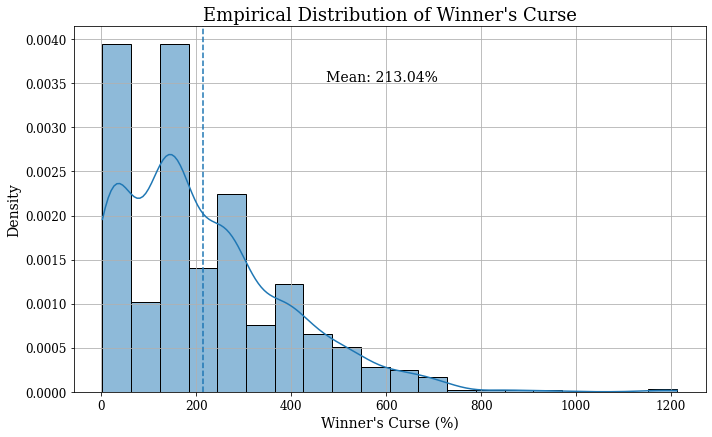

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(mle_emp_wc_pct_arr, bins=20, kde=True, stat='density', ax=ax, color='C0')
ax.axvline(mle_emp_wc_pct_arr.mean(), color='C0', linestyle='--')
ax.annotate(
    f"Mean: {mle_emp_wc_pct_arr.mean():.2f}%", 
    xy=(0.4, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
ax.set_title("Empirical Distribution of Winner's Curse", fontsize=title_size)

ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.set_xlabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
# plt.savefig('figures/case1-winners-curse-dstn.png')
plt.show()

In [28]:
data_params = {'sample_size': 7866, 'n_customers': 100}
experiment_params = {'n_experiments': 1000, 'in_sample': False, 'demand_model': 'lasso'}

estimators_dict = {}

result_records = pricing.repeated_experiments(
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

lasso_emp_wc_arr = np.array([record['plugin_wc'] for record in result_records])
lasso_emp_wc_pct_arr = 100 * np.array([record['plugin_wc_pct'] for record in result_records])
avg_lasso_emp_wc_pct = lasso_emp_wc_pct_arr.mean()
se_lasso_emp_wc_pct = lasso_emp_wc_pct_arr.std() / np.sqrt(data_params['sample_size'])

print(f"Winner's Curse: {avg_lasso_emp_wc_pct:.4f}% ({se_lasso_emp_wc_pct:.4f}%)")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   13.1s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:   23.0s


Winner's Curse: 9.2039% (0.0620%)


[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   29.9s finished


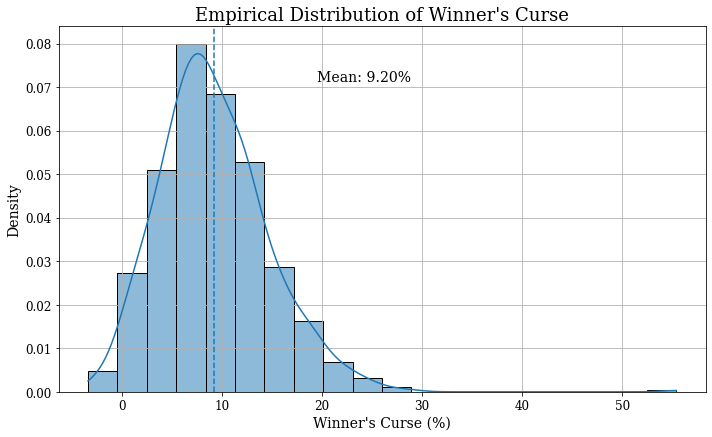

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(lasso_emp_wc_pct_arr, bins=20, kde=True, stat='density', ax=ax, color='C0')
ax.axvline(lasso_emp_wc_pct_arr.mean(), color='C0', linestyle='--')
ax.annotate(
    f"Mean: {lasso_emp_wc_pct_arr.mean():.2f}%", 
    xy=(0.4, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
ax.set_title("Empirical Distribution of Winner's Curse", fontsize=title_size)

ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.set_xlabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
# plt.savefig('figures/case1-winners-curse-dstn.png')
plt.show()

In [25]:
data_params = {'sample_size': 7866, 'n_customers': 100}
experiment_params = {'n_experiments': 1000, 'in_sample': False, 'demand_model': 'wlb-lasso'}

estimators_dict = {}

result_records = pricing.repeated_experiments(
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

wlb_emp_wc_arr = np.array([record['plugin_wc'] for record in result_records])
wlb_emp_wc_pct_arr = 100 * np.array([record['plugin_wc_pct'] for record in result_records])
avg_wlb_emp_wc_pct = wlb_emp_wc_pct_arr.mean()
se_wlb_emp_wc_pct = wlb_emp_wc_pct_arr.std() / np.sqrt(wlb_emp_wc_pct_arr.size)

print(f"Winner's Curse: {avg_wlb_emp_wc_pct:.4f}% ({se_wlb_emp_wc_pct:.4f}%)")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


KeyboardInterrupt: 

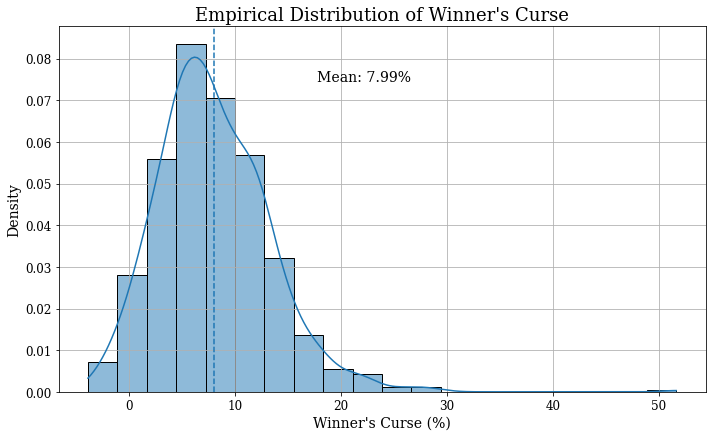

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wlb_emp_wc_pct_arr, bins=20, kde=True, stat='density', ax=ax, color='C0')
ax.axvline(wlb_emp_wc_pct_arr.mean(), color='C0', linestyle='--')
ax.annotate(
    f"Mean: {wlb_emp_wc_pct_arr.mean():.2f}%", 
    xy=(0.4, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
ax.set_title("Empirical Distribution of Winner's Curse", fontsize=title_size)

ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.set_xlabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
# plt.savefig('figures/case1-winners-curse-dstn.png')
plt.show()

# Estimating Winner's Curse

## Standard Bootstrap

In [11]:
boot_wc_dstn_arr = pricing.get_wc_boot_dstn(
    data=train_df, target_customers=test_customers, 
    demand_model='lasso', 
    n_bootstraps=500, verbose=True, n_jobs=-1
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    4.9s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:   12.0s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   24.2s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   27.9s finished


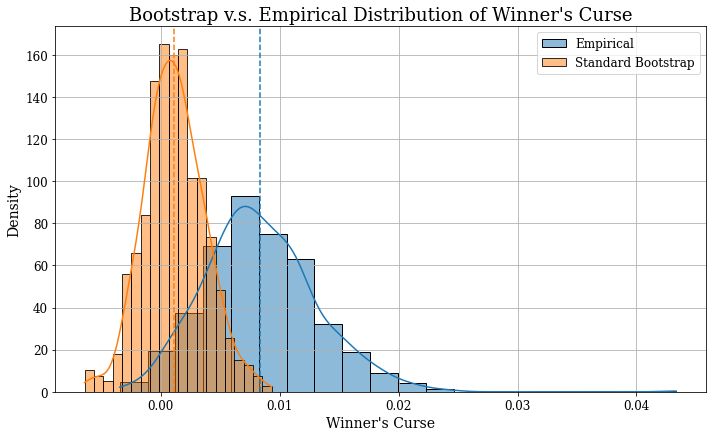

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(lasso_emp_wc_arr, bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(lasso_emp_wc_arr.mean(), color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C1', label='Standard Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C1', linestyle='--')

ax.set_title("Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.legend(loc='upper right', fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [24]:
mn_boot_wc_dstn_arr = pricing.get_wc_m_out_of_n_boot_dstn(
    data=train_df, target_customers=test_customers, 
    demand_model='lasso', power=0.86, 
    n_bootstraps=500, verbose=True, n_jobs=-1
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    4.3s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:    9.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   11.5s finished


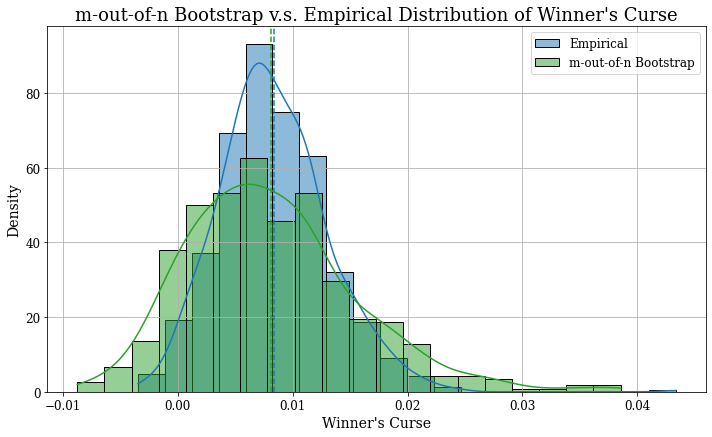

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(lasso_emp_wc_arr, bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(lasso_emp_wc_arr.mean(), color='C0', linestyle='--')

sns.histplot(mn_boot_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C2', label='m-out-of-n Bootstrap')
ax.axvline(mn_boot_wc_dstn_arr.mean(), color='C2', linestyle='--')

ax.set_title("m-out-of-n Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.legend(loc='upper right', fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [26]:
num_boot_wc_dstn_arr = pricing.get_wc_num_boot_dstn(
    data=train_df, target_customers=test_customers, 
    demand_model='lasso', n_bootstraps=500, power=-0.35, verbose=True
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    7.0s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   16.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   18.5s finished


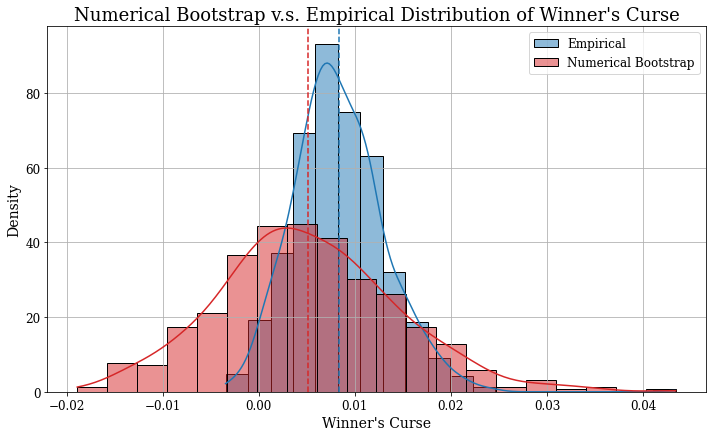

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(lasso_emp_wc_arr, bins=20, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(lasso_emp_wc_arr.mean(), color='C0', linestyle='--')

sns.histplot(num_boot_wc_dstn_arr, bins=20, kde=True, stat='density', ax=ax, color='C3', label='Numerical Bootstrap')
ax.axvline(num_boot_wc_dstn_arr.mean(), color='C3', linestyle='--')

ax.set_title("Numerical Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.legend(loc='upper right', fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

# Bias Correction

In [19]:
data_params = {'sample_size': 7866, 'n_customers': 100}
experiment_params = {'n_experiments': 1000, 'in_sample': False, 'demand_model': 'lasso'}

estimators_dict = {
    'bootstrap_correction': {
        'estimator': pricing.bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'standard', 'n_bootstraps': 100, 'n_jobs': 1}
    }, 
    'mn_boot_correction': {
        'estimator': pricing.bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.90, 'n_jobs': 1}
    }, 
    'num_boot_correction': {
        'estimator': pricing.bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.30, 'n_jobs': 1}
    }
}

result_records = pricing.repeated_experiments(
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:  3.6min
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed: 19.4min
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed: 42.6min
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed: 74.3min
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed: 359.3min finished


plugin: 9.20% (0.06%)
bootstrap_correction: 7.72% (0.06%)
mn_boot_correction: -0.60% (0.04%)
num_boot_correction: 0.48% (0.07%)


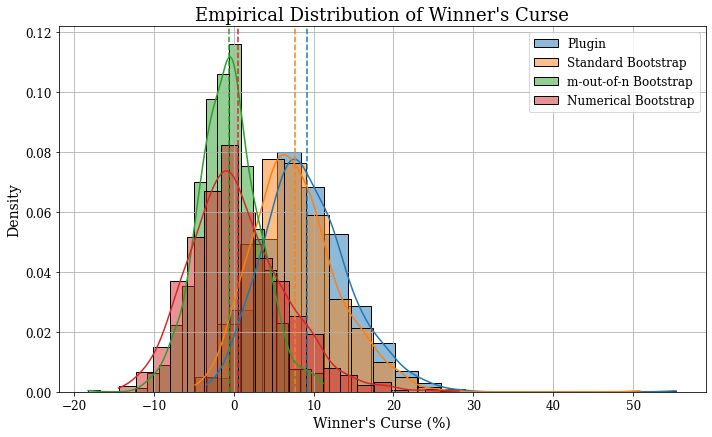

In [20]:
result_df = pd.DataFrame.from_records(result_records)
wc_df = 100 * result_df[[col for col in result_df.columns if col.endswith('wc_pct')]].copy()
wc_df.rename(columns={col: col.replace('_wc_pct', '') for col in wc_df.columns}, inplace=True)

# print
for col in wc_df.columns:
    avg_wc = wc_df[col].mean()
    se_wc = wc_df[col].std() / np.sqrt(data_params['sample_size'])

    print(f"{col}: {avg_wc:.2f}% ({se_wc:.2f}%)")

# plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_df['plugin'], bins=20, kde=True, stat='density', ax=ax, color='C0', label='Plugin')
ax.axvline(wc_df['plugin'].mean(), color='C0', linestyle='--')

sns.histplot(wc_df['bootstrap_correction'], bins=20, kde=True, stat='density', ax=ax, color='C1', label='Standard Bootstrap')
ax.axvline(wc_df['bootstrap_correction'].mean(), color='C1', linestyle='--')

sns.histplot(wc_df['mn_boot_correction'], bins=20, kde=True, stat='density', ax=ax, color='C2', label='m-out-of-n Bootstrap')
ax.axvline(wc_df['mn_boot_correction'].mean(), color='C2', linestyle='--')

sns.histplot(wc_df['num_boot_correction'], bins=20, kde=True, stat='density', ax=ax, color='C3', label='Numerical Bootstrap')
ax.axvline(wc_df['num_boot_correction'].mean(), color='C3', linestyle='--')

ax.set_title("Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.legend(loc='upper right', fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

# Sensitivity Analysis

## Hyperparameters

In [37]:
data_params = {'sample_size': 1000, 'n_customers': 100}
experiment_params = {'n_experiments': 100, 'in_sample': False, 'demand_model': 'lasso'}

estimators_dict = {
    'bootstrap_correction': {
        'estimator': pricing.bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'standard', 'n_bootstraps': 100}
    }, 
    'mn_boot_correction': {
        'estimator': pricing.bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': np.nan}
    }, 
}

In [ ]:
power_list = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
sample_size_list = [1000, 2000, 3000, 4000, 5000]
result_dict = {(sample_size, power): None for sample_size in sample_size_list for power in power_list}

for sample_size in sample_size_list:
    for power in power_list: 
        print(f'\nSample size = {sample_size}, Power = {power}')
        data_params['sample_size'] = sample_size
        estimators_dict['mn_boot_correction']['params']['power'] = power
        
        result_records = pricing.repeated_experiments(
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict, 
            verbose=True
        )

        wc_df = pd.DataFrame({
            name: np.array([record[f'{name}_wc'] for record in result_records]) 
            for name in list(estimators_dict.keys()) + ['plugin']
        })

        result_dict[(sample_size, power)] = {
            f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
        }

        result_dict[(sample_size, power)].update({
            f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
            for col in wc_df.columns
        })

with open('results/case5_mnb_hyperparam_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

In [14]:
with open('results/case5_mnb_hyperparam_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame(result_dict).T.reset_index().rename(columns={'level_0': 'sample_size', 'level_1': 'power'})

sample_size_arr = np.unique(result_df['sample_size'])
power_arr = np.unique(result_df['power'])

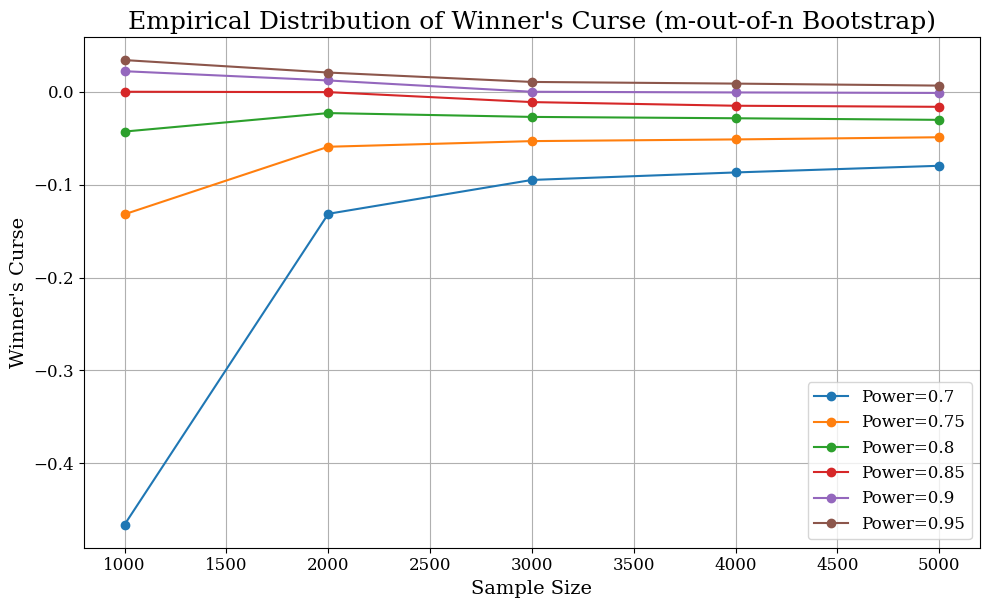

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# for sample_size in sample_size_arr:
#     sub_df = result_df[result_df['sample_size'] == sample_size]
#     ax.plot(
#         sub_df['power'], sub_df['mn_boot_correction_mean'], 
#         marker='o', label=f"Sample Size={sample_size}"
#     )

for power in power_arr:
    sub_df = result_df[result_df['power'] == power]
    ax.plot(
        sub_df['sample_size'], sub_df['mn_boot_correction_mean'], 
        marker='o', label=f"Power={power}"
    )

ax.set_title(f"Empirical Distribution of Winner's Curse (m-out-of-n Bootstrap)", fontsize=title_size)
ax.set_xlabel("Sample Size", fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse", fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

In [59]:
data_params = {'sample_size': 1000, 'n_customers': 100}
experiment_params = {'n_experiments': 100, 'in_sample': False, 'demand_model': 'lasso'}

estimators_dict = {
    'bootstrap_correction': {
        'estimator': pricing.bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'standard', 'n_bootstraps': 100}
    }, 
    'num_boot_correction': {
        'estimator': pricing.bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': np.nan}
    }
}

In [ ]:
power_list = [-0.25, -0.30, -0.35, -0.40, -0.45]
sample_size_list = [1000, 2000, 3000, 4000, 5000]
result_dict = {(sample_size, power): None for sample_size in sample_size_list for power in power_list}

for sample_size in sample_size_list:
    for power in power_list: 
        print(f'\nSample size = {sample_size}, Power = {power}')
        data_params['sample_size'] = sample_size
        estimators_dict['num_boot_correction']['params']['power'] = power
        
        result_records = pricing.repeated_experiments(
            data_params=data_params, 
            experiment_params=experiment_params, 
            estimators_dict=estimators_dict, 
            verbose=True
        )

        wc_df = pd.DataFrame({
            name: np.array([record[f'{name}_wc'] for record in result_records]) 
            for name in list(estimators_dict.keys()) + ['plugin']
        })

        result_dict[(sample_size, power)] = {
            f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
        }

        result_dict[(sample_size, power)].update({
            f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
            for col in wc_df.columns
        })

with open('results/case5_numb_hyperparam_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

In [11]:
with open('results/case5_numb_hyperparam_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame(result_dict).T.reset_index().rename(columns={'level_0': 'sample_size', 'level_1': 'power'})

sample_size_arr = np.unique(result_df['sample_size'])
power_arr = np.unique(result_df['power'])

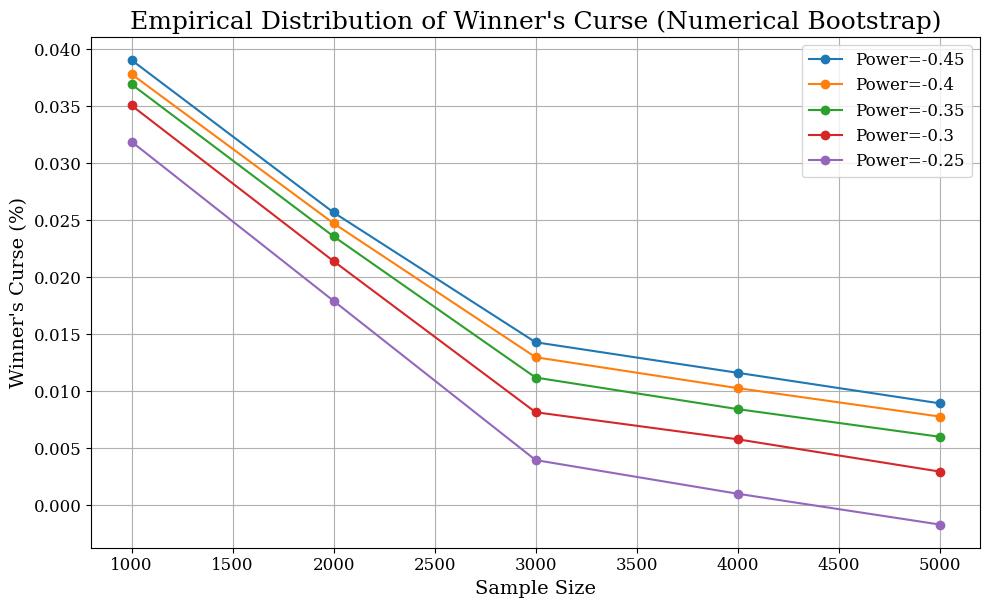

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# for sample_size in sample_size_arr:
#     sub_df = result_df[result_df['sample_size'] == sample_size]
#     ax.plot(
#         sub_df['power'], sub_df['num_boot_correction_mean'], 
#         marker='o', label=f"Sample Size={sample_size}"
#     )

for power in power_arr:
    sub_df = result_df[result_df['power'] == power]
    ax.plot(
        sub_df['sample_size'], sub_df['num_boot_correction_mean'], 
        marker='o', label=f"Power={power}"
    )

ax.set_title(f"Empirical Distribution of Winner's Curse (Numerical Bootstrap)", fontsize=title_size)
ax.set_xlabel("Sample Size", fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## Sample Size 

In [14]:
data_params = {'sample_size': np.nan, 'n_customers': 100}
experiment_params = {'n_experiments': 100, 'in_sample': False, 'demand_model': 'lasso'}

estimators_dict = {
    'bootstrap_correction': {
        'estimator': pricing.bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'standard', 'n_bootstraps': 100}
    }, 
    'mn_boot_correction': {
        'estimator': pricing.bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.90}
    }, 
    'num_boot_correction': {
        'estimator': pricing.bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.3}
    }
}

In [ ]:
sample_size_list = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample size = {sample_size}')
    data_params['sample_size'] = sample_size
    result_dict[sample_size] = {}

    result_records = pricing.repeated_experiments(
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True
    )

    wc_df = pd.DataFrame({
        name: np.array([record[f'{name}_wc'] for record in result_records]) 
        for name in list(estimators_dict.keys()) + ['plugin']
    })

    result_dict[sample_size].update({
        f'{col}_mean': wc_df[col].mean() for col in wc_df.columns
    })

    result_dict[sample_size].update({
        f'{col}_se': wc_df[col].std() / np.sqrt(data_params['sample_size'])
        for col in wc_df.columns
    })

    wc_pct_df = pd.DataFrame({
        name: np.array([record[f'{name}_wc_pct'] for record in result_records]) 
        for name in list(estimators_dict.keys()) + ['plugin']
    })

    result_dict[sample_size].update({
        f'{col}_pct_mean': wc_pct_df[col].mean() for col in wc_pct_df.columns
    })

    result_dict[sample_size].update({
        f'{col}_pct_se': wc_pct_df[col].std() / np.sqrt(data_params['sample_size'])
        for col in wc_pct_df.columns
    })

with open('results/case5_sample_size_test.pkl', 'wb') as f:
    pickle.dump(result_dict, f)

In [15]:
with open('results/case5_sample_size_test.pkl', 'rb') as f:
    result_dict = pickle.load(f)

result_df = pd.DataFrame(result_dict).T.reset_index().rename(columns={'index': 'sample_size'})

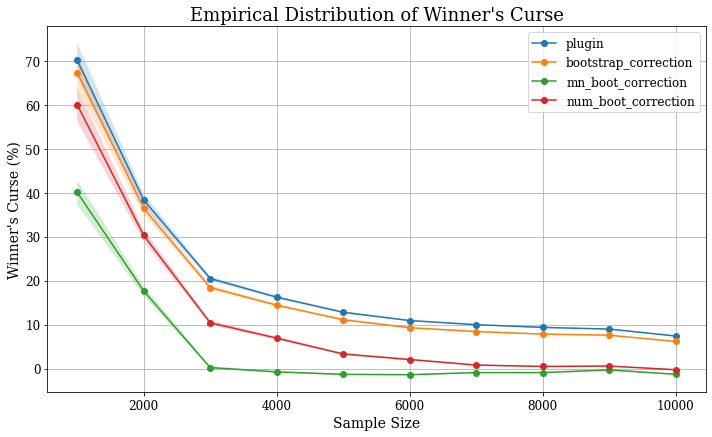

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

for col in ['plugin'] + list(estimators_dict.keys()):
    ax.plot(
        result_df['sample_size'], 100 * result_df[f'{col}_pct_mean'], 
        marker='o', label=col
    )
    ax.fill_between(
        result_df['sample_size'], 
        100 * (result_df[f'{col}_pct_mean'] - 1.96 * result_df[f'{col}_pct_se']), 
        100 * (result_df[f'{col}_pct_mean'] + 1.96 * result_df[f'{col}_pct_se']), 
        alpha=0.2
    )

ax.set_title("Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Sample Size", fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

In [18]:
sample_size = 8000

for estimator in ['plugin'] + list(estimators_dict.keys()):
    avg_wc_pct = 100 * result_df[result_df['sample_size'] == sample_size][f'{estimator}_pct_mean'].values[0]
    se_wc_pct = 100 * result_df[result_df['sample_size'] == sample_size][f'{estimator}_pct_se'].values[0]

    print(f"{estimator}: {avg_wc_pct:.2f}% ({se_wc_pct:.2f}%)")


plugin: 9.36% (0.07%)
bootstrap_correction: 7.84% (0.07%)
mn_boot_correction: -0.92% (0.05%)
num_boot_correction: 0.48% (0.07%)


In [17]:
sample_size = 3000

for estimator in ['plugin'] + list(estimators_dict.keys()):
    avg_wc_pct = 100 * result_df[result_df['sample_size'] == sample_size][f'{estimator}_pct_mean'].values[0]
    se_wc_pct = 100 * result_df[result_df['sample_size'] == sample_size][f'{estimator}_pct_se'].values[0]

    print(f"{estimator}: {avg_wc_pct:.2f}% ({se_wc_pct:.2f}%)")


plugin: 20.49% (0.26%)
bootstrap_correction: 18.43% (0.26%)
mn_boot_correction: 0.22% (0.15%)
num_boot_correction: 10.41% (0.27%)


## Number of Customers